In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
import numpy as np
import xgboost as xgb
from pathlib import Path

In [3]:
df=pd.DataFrame(pd.read_csv("C:/Users/Thirtesh/Desktop/Project/bangalore_house_price/Dataset/Bengaluru_House_Data.csv"))

In [22]:
display(df.shape)
display(df.describe())

(13320, 9)

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [23]:
df.groupby('area_type')['area_type'].aggregate('count')

area_type
Built-up  Area          2418
Carpet  Area              87
Plot  Area              2025
Super built-up  Area    8790
Name: area_type, dtype: int64

In [24]:
data1=df[['area_type','location','size','total_sqft','bath','balcony','price']].copy()
data1.head()

,area_type,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [25]:
display(data1.isnull().sum())
data2=data1.dropna()
display(data2.isnull().sum())
data2.shape

area_type       0
location        1
size           16
total_sqft      0
bath           73
balcony       609
price           0
dtype: int64

area_type     0
location      0
size          0
total_sqft    0
bath          0
balcony       0
price         0
dtype: int64

(12710, 7)

In [26]:
display(data2['size'].unique())
data2['size']=data2['size'].apply(lambda x: x.split()[0])

<ArrowStringArray>
[     '2 BHK',  '4 Bedroom',      '3 BHK',  '3 Bedroom',      '1 BHK',
       '1 RK',      '4 BHK',  '1 Bedroom',  '2 Bedroom',  '6 Bedroom',
  '8 Bedroom',  '7 Bedroom',      '5 BHK',      '7 BHK',      '6 BHK',
  '5 Bedroom',     '11 BHK',      '9 BHK',  '9 Bedroom',     '27 BHK',
 '11 Bedroom', '43 Bedroom',     '14 BHK',      '8 BHK', '12 Bedroom',
 '10 Bedroom',     '13 BHK']
Length: 27, dtype: str

In [27]:
display(data2['size'].unique())
data2.rename(columns={'size':'bhk'}, inplace=True)
data2.head()

<ArrowStringArray>
[ '2',  '4',  '3',  '1',  '6',  '8',  '7',  '5', '11',  '9', '27', '43', '14',
 '12', '10', '13']
Length: 16, dtype: str

,area_type,location,bhk,total_sqft,bath,balcony,price
0,Super built-up Area,Electronic City Phase II,2,1056,2.0,1.0,39.07
1,Plot Area,Chikka Tirupathi,4,2600,5.0,3.0,120.00
2,Built-up Area,Uttarahalli,3,1440,2.0,3.0,62.00
3,Super built-up Area,Lingadheeranahalli,3,1521,3.0,1.0,95.00
4,Super built-up Area,Kothanur,2,1200,2.0,1.0,51.00


In [28]:
data2['total_sqft']=data2['total_sqft'].where(data2['total_sqft'].str.isdigit())
data2=data2.dropna()
display(data2.head())
data2.shape

,area_type,location,bhk,total_sqft,bath,balcony,price
0,Super built-up Area,Electronic City Phase II,2,1056,2.0,1.0,39.07
1,Plot Area,Chikka Tirupathi,4,2600,5.0,3.0,120.00
2,Built-up Area,Uttarahalli,3,1440,2.0,3.0,62.00
3,Super built-up Area,Lingadheeranahalli,3,1521,3.0,1.0,95.00
4,Super built-up Area,Kothanur,2,1200,2.0,1.0,51.00


(12438, 7)

In [29]:
data2['price']=data2['price'].astype(float)
data2['total_sqft']=data2['total_sqft'].astype(float)
data2['bhk']=data2['bhk'].astype(int)
data2['bath']=data2['bath'].astype(int)
data2['balcony']=data2['balcony'].astype(int)
data2.head()

,area_type,location,bhk,total_sqft,bath,balcony,price
0,Super built-up Area,Electronic City Phase II,2,1056.0,2,1,39.07
1,Plot Area,Chikka Tirupathi,4,2600.0,5,3,120.00
2,Built-up Area,Uttarahalli,3,1440.0,2,3,62.00
3,Super built-up Area,Lingadheeranahalli,3,1521.0,3,1,95.00
4,Super built-up Area,Kothanur,2,1200.0,2,1,51.00


In [30]:
data2['price_per_sqft']=data2['price']*100000/data2['total_sqft']
data2.head()

,area_type,location,bhk,total_sqft,bath,balcony,price,price_per_sqft
0,Super built-up Area,Electronic City Phase II,2,1056.0,2,1,39.07,3699.810606
1,Plot Area,Chikka Tirupathi,4,2600.0,5,3,120.00,4615.384615
2,Built-up Area,Uttarahalli,3,1440.0,2,3,62.00,4305.555556
3,Super built-up Area,Lingadheeranahalli,3,1521.0,3,1,95.00,6245.890861
4,Super built-up Area,Kothanur,2,1200.0,2,1,51.00,4250.000000


In [34]:
data2['location']=data2['location'].apply(lambda a: a.strip())
len(data2['location'].unique())

1246

In [32]:
locations=data2.groupby('location')['location'].agg('count').sort_values(ascending=False)
display(locations)

location
Whitefield                      499
Sarjapur  Road                  365
Electronic City                 302
Kanakpura Road                  250
Thanisandra                     222
                               ... 
2nd phase jp nagar, jp nagar      1
1 Giri Nagar                      1
1st Stage Domlur                  1
vinayakanagar                     1
t.c palya                         1
Name: location, Length: 1246, dtype: int64

In [33]:
display(len(locations[locations<10]))
locations_less10 = locations[locations<10]
locations_less10

999

location
KUDLU MAIN ROAD                 9
Nagadevanahalli                 9
2nd Phase JP Nagar              9
5th Block Hbr Layout            9
Banagiri Nagar                  9
                               ..
2nd phase jp nagar, jp nagar    1
1 Giri Nagar                    1
1st Stage Domlur                1
vinayakanagar                   1
t.c palya                       1
Name: location, Length: 999, dtype: int64

In [16]:
data2['location']=data2['location'].apply(lambda x: 'Others' if x in locations_less10 else x)
pd.DataFrame(data2.head())

,area_type,location,bhk,total_sqft,bath,balcony,price,price_per_sqft
0,Super built-up Area,Electronic City Phase II,2,1056.0,2,1,39.07,3699.810606
1,Plot Area,Chikka Tirupathi,4,2600.0,5,3,120.00,4615.384615
2,Built-up Area,Uttarahalli,3,1440.0,2,3,62.00,4305.555556
3,Super built-up Area,Lingadheeranahalli,3,1521.0,3,1,95.00,6245.890861
4,Super built-up Area,Kothanur,2,1200.0,2,1,51.00,4250.000000


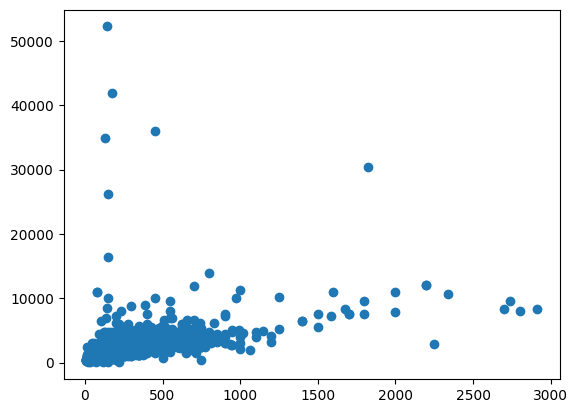

In [17]:
plt.scatter(data2['price'], data2['total_sqft'])

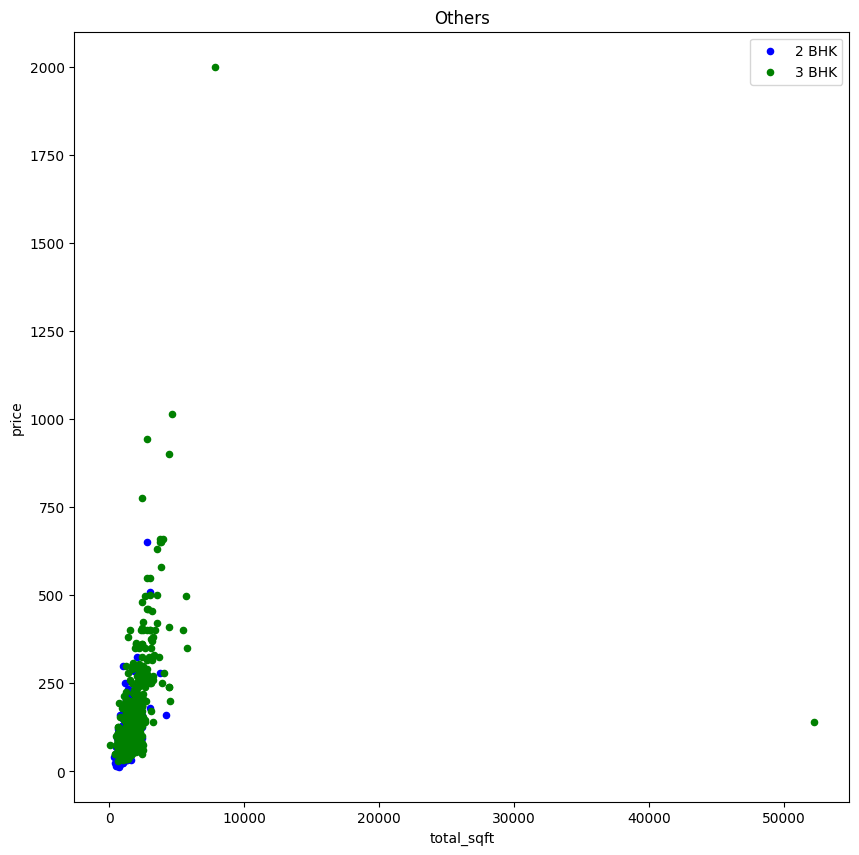

In [18]:
def scatter_plot(df,location):
    bhk2 = df[(df.location == location) & (df.bhk == 2)]
    bhk3 = df[(df.location == location) & (df.bhk == 3)]
    plt.rcParams["figure.figsize"] = (10,10)
    plt.scatter(bhk2.total_sqft, bhk2.price, color='blue', label = '2 BHK', s=20)
    plt.scatter(bhk3.total_sqft, bhk3.price, color='green', label = '3 BHK', s=20)
    plt.xlabel("total_sqft")
    plt.ylabel("price")
    plt.title(location)
    plt.legend()
    
scatter_plot(data2, "Others")

In [19]:
display(data2[data2.bath>data2.bhk+2])
data=data2[data2.bath<data2.bhk+2]
data.head(3)

,area_type,location,bhk,total_sqft,bath,balcony,price,price_per_sqft
1979,Plot Area,Others,8,990.0,12,0,120.0,12121.212121
2620,Super built-up Area,Others,6,11338.0,9,1,1000.0,8819.897689
6838,Super built-up Area,Rajaji Nagar,5,7500.0,8,3,1700.0,22666.666667
7709,Built-up Area,Chikkabanavar,4,2460.0,7,2,80.0,3252.032520
9974,Plot Area,Others,3,2400.0,6,2,775.0,32291.666667
9990,Plot Area,Others,6,1200.0,9,3,122.0,10166.666667
11645,Plot Area,Chamrajpet,6,1500.0,9,3,230.0,15333.333333
12103,Super built-up Area,Thanisandra,3,1806.0,6,2,116.0,6423.034330


,area_type,location,bhk,total_sqft,bath,balcony,price,price_per_sqft
0,Super built-up Area,Electronic City Phase II,2,1056.0,2,1,39.07,3699.810606
1,Plot Area,Chikka Tirupathi,4,2600.0,5,3,120.00,4615.384615
2,Built-up Area,Uttarahalli,3,1440.0,2,3,62.00,4305.555556


In [20]:
display(data.shape)

df_out=pd.DataFrame()
for _, subdf in data.groupby('location'):
    m = subdf.price_per_sqft.mean()
    st = subdf.price_per_sqft.std()
    reduced_df = subdf[(subdf.price_per_sqft > (m - st)) & (subdf.price_per_sqft <= (m + st))]
    df_out = pd.concat([df_out, reduced_df], ignore_index=True)
data=pd.DataFrame(df_out)
data.shape

(12311, 8)

(10553, 8)

In [21]:
data=data.drop(['area_type','balcony','price_per_sqft'], axis=1)

In [ ]:
data.head()

In [ ]:
ohe = sk.preprocessing.OneHotEncoder(handle_unknown='ignore', sparse_output=False)
data_ohe=ohe.fit_transform(data[['location']])
data_ohe = pd.DataFrame(data_ohe, columns=ohe.get_feature_names_out(['location']))
if 'location_other' in data_ohe.columns:
    data_ohe = data_ohe.drop('location_others', axis=1)

In [ ]:
data_final=pd.concat([data.drop('location', axis=1), data_ohe], axis=1)
data_final.head()

In [ ]:
X=data_final.drop('price', axis=1)
y=data_final.price

In [ ]:
X_train, X_test, y_train, y_test= sk.model_selection.train_test_split(X,y,random_state=77, test_size=0.2)
y_train=np.log1p(y_train)
y_test=np.log1p(y_test)

In [ ]:
pipe = sk.pipeline.make_pipeline(sk.preprocessing.StandardScaler(), xgb.XGBRegressor())
print(pd.DataFrame(pipe.get_params().keys()))

In [ ]:
param={ 'xgbregressor__learning_rate': [0.3],
        'xgbregressor__max_depth':[6],
        'xgbregressor__n_estimators':[150],
        'xgbregressor__colsample_bytree':[0.3]
}#If you're wondering why there's only one value per paramter, the hyper parameters are tuned and are set to the best possible value to reduce runtime
grid= sk.model_selection.RandomizedSearchCV(pipe, param_distributions=param, cv=5, random_state=77, scoring='r2', n_iter=1, n_jobs=-1) 

In [ ]:
grid.fit(X_train, y_train)
print('done')

In [ ]:
grid.score(X_test,y_test)


In [ ]:
import joblib as jb
import os
fd=os.path.expanduser('~/Desktop/Project/real_estate/Model/model.joblib')
fd1=os.path.expanduser('~/Desktop/Project/real_estate/Model/OHE.joblib')
jb.dump(grid, fd)
jb.dump(ohe,fd1)